### Importing Libraries

In [95]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

### Loading Dataset

In [96]:
df = pd.read_csv(r"C:\Users\ĀḌṀĪṆ\Downloads\framingham.csv")
df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0


### Data Inspection

In [97]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [98]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4233,1,50,1.0,1,1.0,0.0,0,1,0,313.0,179.0,92.0,25.97,66.0,86.0,1
4234,1,51,3.0,1,43.0,0.0,0,0,0,207.0,126.5,80.0,19.71,65.0,68.0,0
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0


In [99]:
df.shape

(4238, 16)

In [100]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


### Statistical Description

In [102]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [103]:
#mean
df.mean(numeric_only=True)

male                 0.429212
age                 49.584946
education            1.978950
currentSmoker        0.494101
cigsPerDay           9.003089
BPMeds               0.029630
prevalentStroke      0.005899
prevalentHyp         0.310524
diabetes             0.025720
totChol            236.721585
sysBP              132.352407
diaBP               82.893464
BMI                 25.802008
heartRate           75.878924
glucose             81.966753
TenYearCHD           0.151958
dtype: float64

In [104]:
#Median
df.median(numeric_only=True)

male                 0.0
age                 49.0
education            2.0
currentSmoker        0.0
cigsPerDay           0.0
BPMeds               0.0
prevalentStroke      0.0
prevalentHyp         0.0
diabetes             0.0
totChol            234.0
sysBP              128.0
diaBP               82.0
BMI                 25.4
heartRate           75.0
glucose             78.0
TenYearCHD           0.0
dtype: float64

In [105]:
#Standard deviaton
df.std(numeric_only=True)

male                0.495022
age                 8.572160
education           1.019791
currentSmoker       0.500024
cigsPerDay         11.920094
BPMeds              0.169584
prevalentStroke     0.076587
prevalentHyp        0.462763
diabetes            0.158316
totChol            44.590334
sysBP              22.038097
diaBP              11.910850
BMI                 4.080111
heartRate          12.026596
glucose            23.959998
TenYearCHD          0.359023
dtype: float64

### Missing Data analysis


In [106]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [107]:
#Percentage of missing data

(df.isnull().sum()/len(df))*100

male               0.000000
age                0.000000
education          2.477584
currentSmoker      0.000000
cigsPerDay         0.684285
BPMeds             1.250590
prevalentStroke    0.000000
prevalentHyp       0.000000
diabetes           0.000000
totChol            1.179802
sysBP              0.000000
diaBP              0.000000
BMI                0.448325
heartRate          0.023596
glucose            9.155262
TenYearCHD         0.000000
dtype: float64

In [108]:
#Filling Misssing Values with Mean

imputer = SimpleImputer(strategy='mean')

df[df.columns] = imputer.fit_transform(df)

In [109]:
#checking
df.isnull().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

### Duplicate Data Analysis

In [110]:
#Check Duplicates

df.duplicated().sum()

np.int64(0)

In [111]:
#Removing Dupliactes

df = df.drop_duplicates()

### Target Variable Analysis

In [112]:
#Count Values
df['TenYearCHD'].value_counts()


TenYearCHD
0.0    3594
1.0     644
Name: count, dtype: int64

In [113]:
#Percentage

df['TenYearCHD'].value_counts(normalize=True)*100

TenYearCHD
0.0    84.804153
1.0    15.195847
Name: proportion, dtype: float64

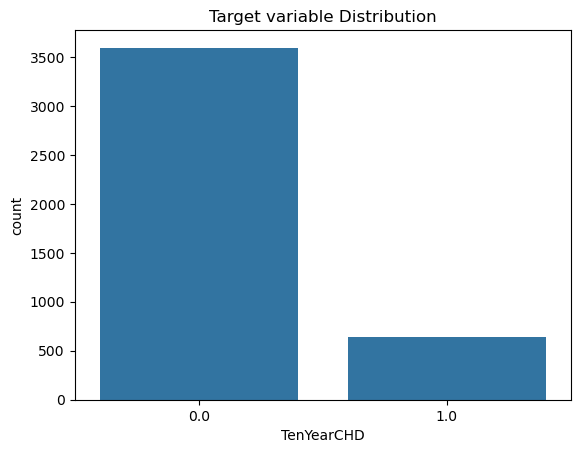

In [114]:
#Count PLot

sns.countplot(x='TenYearCHD', data=df)
plt.title("Target variable Distribution")
plt.show()

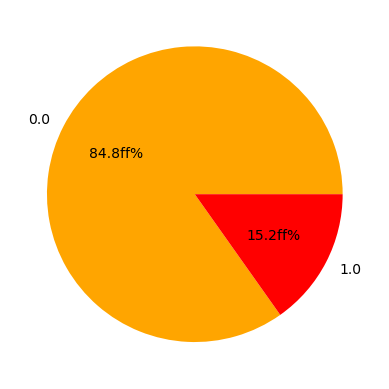

In [115]:
#Pie Chart

df['TenYearCHD'].value_counts().plot(
    kind='pie',
    autopct='%1.1fff%%',
    colors=['orange','red']
)
plt.ylabel("")
plt.show()

#### Univariate Analysis

#Histograms

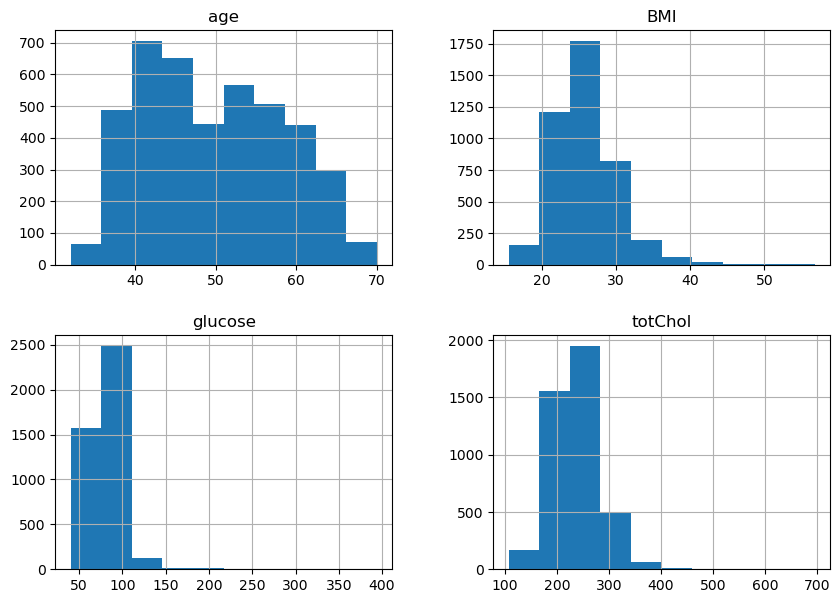

In [116]:
df[['age','BMI','glucose','totChol']].hist(figsize=(10,7))
plt.show()

#Boxplot

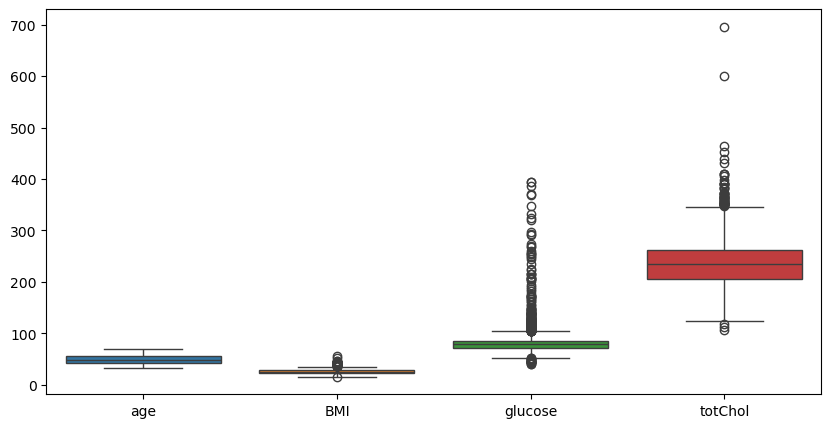

In [117]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df[['age','BMI','glucose','totChol']])

plt.show()

#Count plots
Male

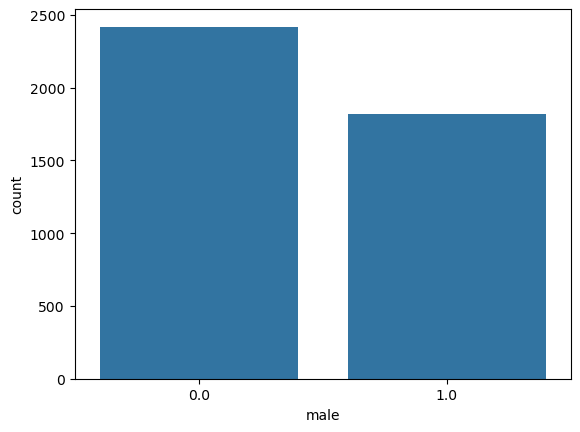

In [118]:
sns.countplot(x='male', data=df)
plt.show()

#Smoker

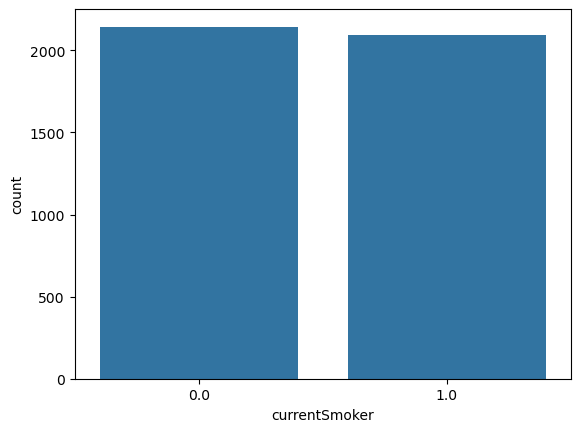

In [119]:
sns.countplot(x='currentSmoker', data=df)
plt.show()

#Diabetes

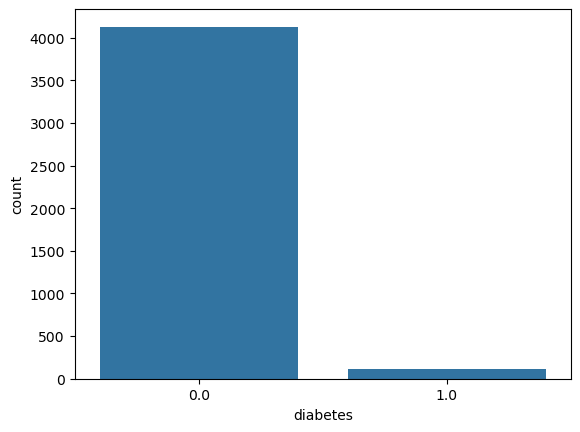

In [120]:
sns.countplot(x='diabetes', data=df)
plt.show()

### Bivariate Analysis

#age vs target

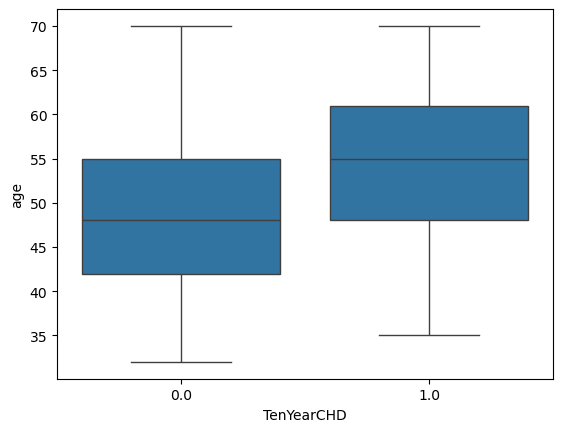

In [121]:
sns.boxplot(x='TenYearCHD', y='age', data=df)
plt.show()

#BMI vs Target

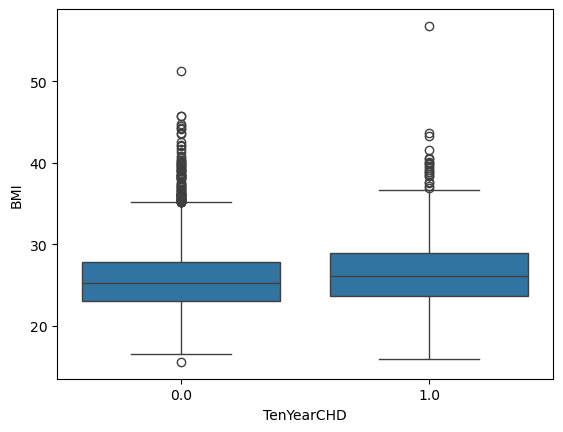

In [122]:
sns.boxplot(x='TenYearCHD', y='BMI', data=df)
plt.show()

#Glucose vs Target

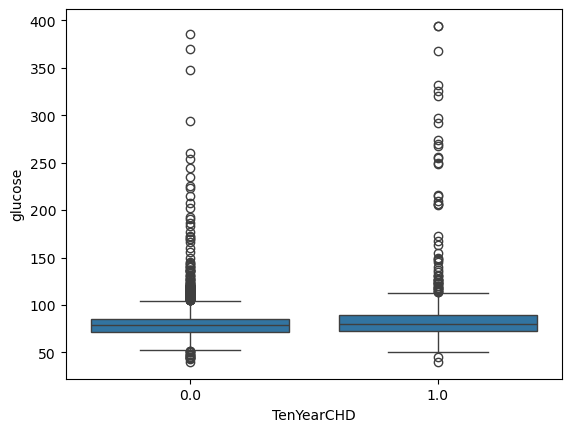

In [123]:
sns.boxplot(x='TenYearCHD', y='glucose', data=df)
plt.show()

#Smoking vs Target

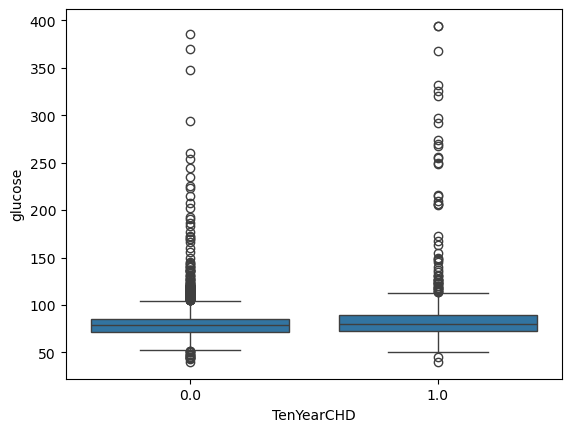

In [124]:
sns.boxplot(x='TenYearCHD', y='glucose', data=df)
plt.show()

#Blood vs Target

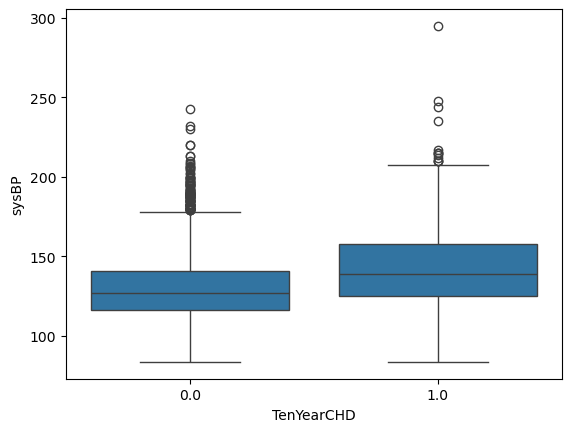

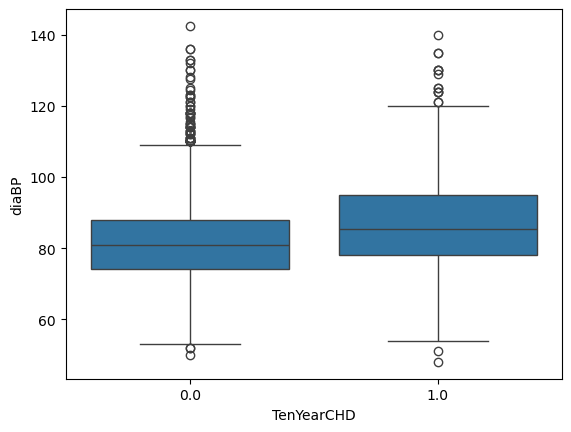

In [125]:
sns.boxplot(x='TenYearCHD', y='sysBP', data=df)
plt.show()

sns.boxplot(x='TenYearCHD', y='diaBP', data=df)
plt.show()

### Correlation Analysis

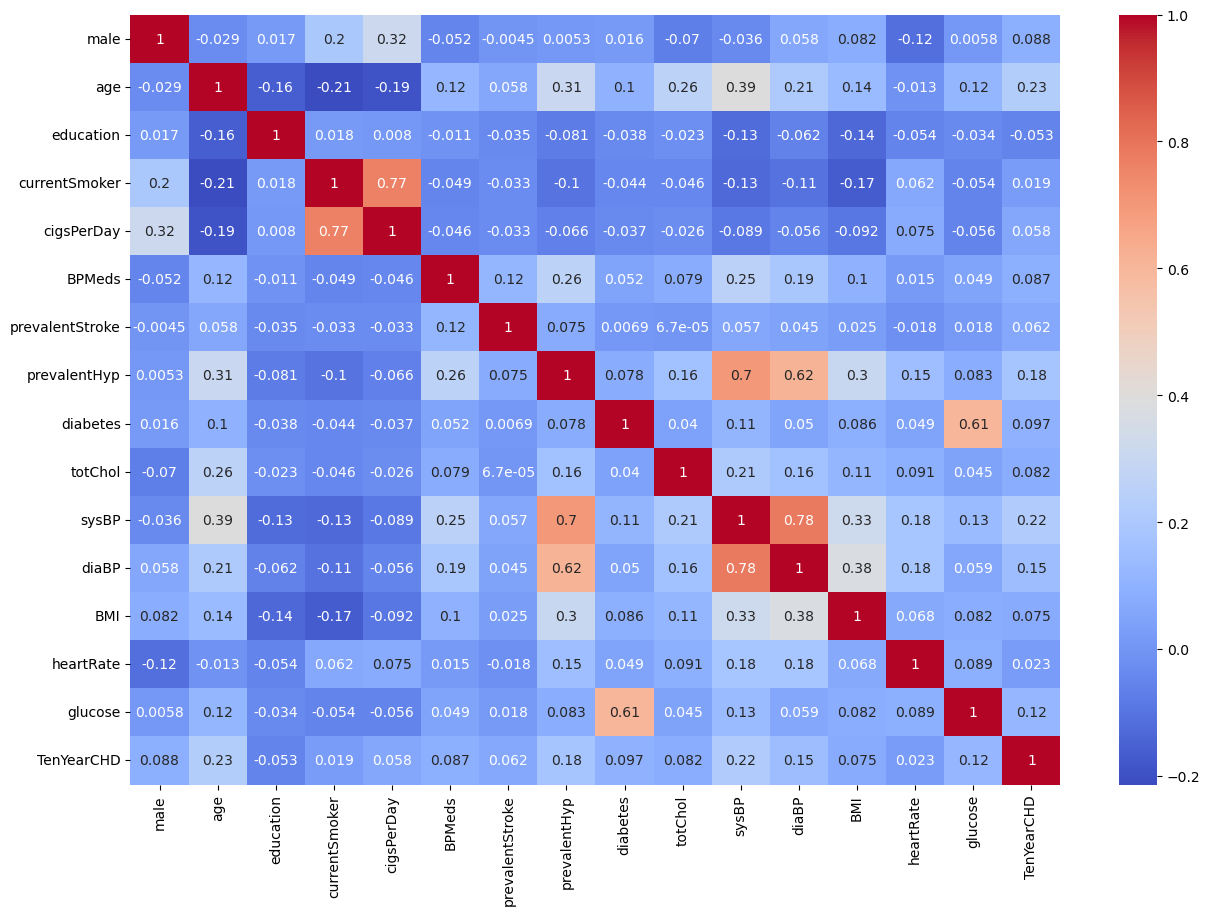

In [128]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

plt.show()

### Outlier Analysis

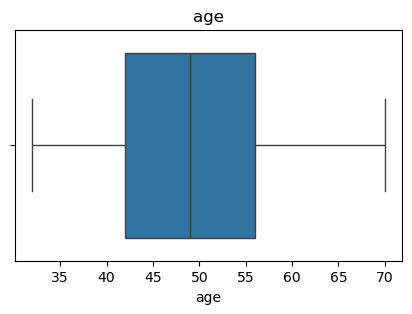

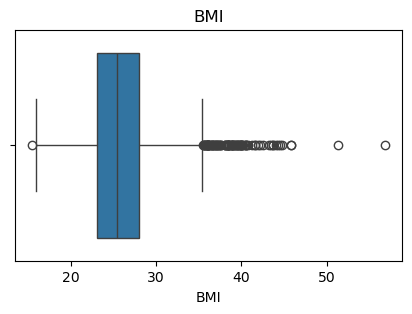

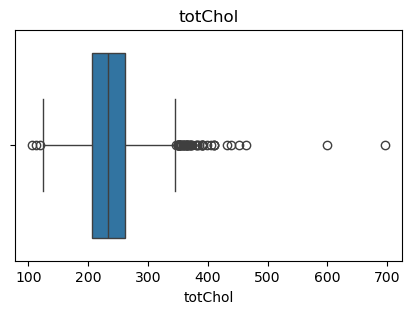

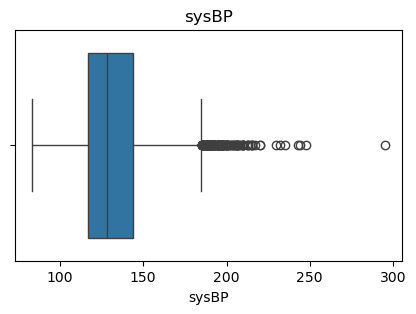

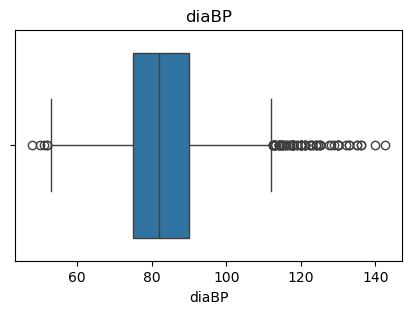

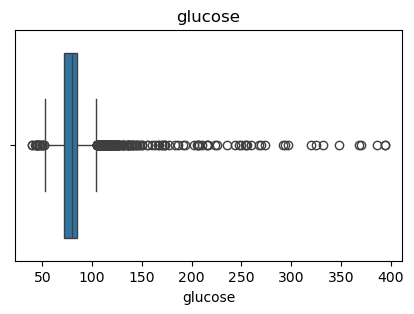

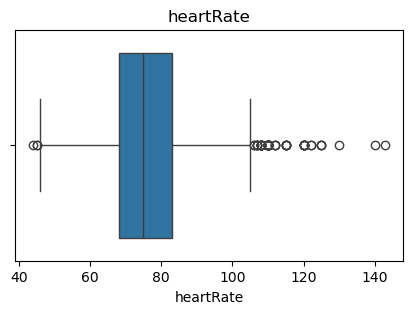

In [127]:
features=['age','BMI','totChol','sysBP','diaBP','glucose','heartRate']

for col in features:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

### Feature Transformation

#Separate features and Target

In [129]:
X = df.drop("TenYearCHD", axis=1)

y = df["TenYearCHD"]

#Feature  Scaling

In [130]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

### Train_test_Split

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Decision Tree Classifier

In [135]:
DT = DecisionTreeClassifier(random_state=42)

DT.fit(X_train, y_train)

y_pred_DT = DT.predict(X_test)

##### Evaluation

In [136]:
print("Accuracy:", accuracy_score(y_test,y_pred_DT))

print(confusion_matrix(y_test,y_pred_DT))

print(classification_report(y_test,y_pred_DT))

Accuracy: 0.7606132075471698
[[612 112]
 [ 91  33]]
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86       724
         1.0       0.23      0.27      0.25       124

    accuracy                           0.76       848
   macro avg       0.55      0.56      0.55       848
weighted avg       0.78      0.76      0.77       848



## Random Forest Classifier

In [137]:
RF = RandomForestClassifier(random_state=42)

RF.fit(X_train,y_train)

y_pred_RF = RF.predict(X_test)

##### Evaluation

In [138]:
print("Accuracy:",accuracy_score(y_test,y_pred_RF))

print(confusion_matrix(y_test,y_pred_RF))

print(classification_report(y_test,y_pred_RF))

Accuracy: 0.8525943396226415
[[711  13]
 [112  12]]
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92       724
         1.0       0.48      0.10      0.16       124

    accuracy                           0.85       848
   macro avg       0.67      0.54      0.54       848
weighted avg       0.81      0.85      0.81       848



##  K-Nearest Neighbors (KNN) Classifier

In [139]:
KNN = KNeighborsClassifier(n_neighbors=5)

KNN.fit(X_train,y_train)

y_pred_KNN = KNN.predict(X_test)

##### Evaluation

In [140]:
print("Accuracy:",accuracy_score(y_test,y_pred_KNN))

print(confusion_matrix(y_test,y_pred_KNN))

print(classification_report(y_test,y_pred_KNN))

Accuracy: 0.8372641509433962
[[693  31]
 [107  17]]
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91       724
         1.0       0.35      0.14      0.20       124

    accuracy                           0.84       848
   macro avg       0.61      0.55      0.55       848
weighted avg       0.79      0.84      0.81       848



## Support Vector Classifier (SVC) Classifier

In [141]:
svc = SVC(kernel='rbf', probability=True, random_state=42)

svc.fit(X_train,y_train)

y_pred_svc = svc.predict(X_test)

##### Evaluation

In [142]:
print("Accuracy:",accuracy_score(y_test,y_pred_svc))

print(confusion_matrix(y_test,y_pred_svc))

print(classification_report(y_test,y_pred_svc))

Accuracy: 0.8549528301886793
[[722   2]
 [121   3]]
              precision    recall  f1-score   support

         0.0       0.86      1.00      0.92       724
         1.0       0.60      0.02      0.05       124

    accuracy                           0.85       848
   macro avg       0.73      0.51      0.48       848
weighted avg       0.82      0.85      0.79       848



### Comparing Accuracy of Models

In [145]:
accuracy = pd.DataFrame({
    'Model':['Decision Tree','Random Forest','KNN','SVC'],
    'Accuracy':[
        accuracy_score(y_test,y_pred_DT),
        accuracy_score(y_test,y_pred_RF),
        accuracy_score(y_test,y_pred_KNN),
        accuracy_score(y_test,y_pred_svc)
    ]
})

print(accuracy)

           Model  Accuracy
0  Decision Tree  0.760613
1  Random Forest  0.852594
2            KNN  0.837264
3            SVC  0.854953


### Precision, Recall, F1-Score

In [146]:
models = {
    "Decision Tree": y_pred_DT,
    "Random Forest": y_pred_RF,
    "KNN": y_pred_KNN,
    "SVC": y_pred_svc
}

for name, pred in models.items():
    print("\n", "="*40)
    print(name)
    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))


Decision Tree
Accuracy : 0.7606132075471698
Precision: 0.22758620689655173
Recall   : 0.2661290322580645
F1 Score : 0.24535315985130113

Random Forest
Accuracy : 0.8525943396226415
Precision: 0.48
Recall   : 0.0967741935483871
F1 Score : 0.1610738255033557

KNN
Accuracy : 0.8372641509433962
Precision: 0.3541666666666667
Recall   : 0.13709677419354838
F1 Score : 0.19767441860465115

SVC
Accuracy : 0.8549528301886793
Precision: 0.6
Recall   : 0.024193548387096774
F1 Score : 0.046511627906976744


### Classification Report

In [148]:
from sklearn.metrics import classification_report

# Decision Tree

DT_pred = DT.predict(X_test)
print("Decision Tree Classification Report")
print(classification_report(y_test, DT_pred))

# Random Forest
RF_pred = RF.predict(X_test)
print("Random Forest Classification Report")
print(classification_report(y_test, RF_pred))

#KNN

KNN_pred = KNN.predict(X_test)
print("K-Nearest Neighbors Classification Report")
print(classification_report(y_test, KNN_pred))

# SVC
svc_pred = svc.predict(X_test)
print("SVC Classification Report")
print(classification_report(y_test, svc_pred))

Decision Tree Classification Report
              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86       724
         1.0       0.23      0.27      0.25       124

    accuracy                           0.76       848
   macro avg       0.55      0.56      0.55       848
weighted avg       0.78      0.76      0.77       848

Random Forest Classification Report
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.92       724
         1.0       0.48      0.10      0.16       124

    accuracy                           0.85       848
   macro avg       0.67      0.54      0.54       848
weighted avg       0.81      0.85      0.81       848

K-Nearest Neighbors Classification Report
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91       724
         1.0       0.35      0.14      0.20       124

    accuracy                           0.84       848
   macro avg  